#### Downloading Hospital Data in Hyderabad from Open Street Map

In [7]:
import osmnx as ox
import geopandas as gpd


place = "Hyderabad, Telangana, India"
tags = {"amenity": "hospital"}
hospitals = ox.features_from_place(place, tags)

hospitals = hospitals[hospitals.geometry.type == "Point"]
hospitals.to_file("hospitals.geojson", driver="GeoJSON")

print("Hospitals data saved!")

Hospitals data saved!


#### Checking Dataset Size


In [8]:
print(len(hospitals))
hospitals.head()

832


geometry addr:district  \
element id                                                   
node    349267517  POINT (78.39166 17.44069)     Hyderabad   
        349270023  POINT (78.38607 17.44443)     Hyderabad   
        513439512  POINT (78.44788 17.44171)           NaN   
        513439517  POINT (78.44803 17.44228)           NaN   
        538425761  POINT (78.44613 17.44154)           NaN   

                                                           addr:full  \
element id                                                             
node    349267517  1-98/90/26, Near IOC Petrol Bunk, Hi-Tech City...   
        349270023  Plot No 8 & 9, Arunodaya Cooperative Housing S...   
        513439512                                                NaN   
        513439517                                                NaN   
        538425761                                                NaN   

                  addr:postcode addr:state   amenity healthcare  \
element id                                                        
node    349267517        500033  Telangana  hospital   hospital   
        349270023        500081  Telangana  hospital   hospital   
        513439512           NaN        NaN  hospital        NaN   
        513439517           NaN        NaN  hospital        NaN   
        538425761           NaN        NaN  hospital        NaN   

                                                   name              source  \
element id                                                                    
node    349267517                      Vikram Hospitals  OpenGovernmentData   
        349270023                       Image Hospitals  OpenGovernmentData   
        513439512          Ameerpet Government Hospital                 NaN   
        513439517                  Sri Vijaya Hospitals                 NaN   
        538425761  Sree Priya Multi Speciality Hospital                 NaN   

                                                 name:te  ... name:hi barrier  \
element id                                                ...                   
node    349267517                                    NaN  ...     NaN     NaN   
        349270023                      ఇమేజ్ హాస్పిటల్స్  ...     NaN     NaN   
        513439512            అమీర్‌పేట ప్రభుత్వ ఆసుపత్రి  ...     NaN     NaN   
        513439517                  శ్రీ విజయ హాస్పిటల్స్  ...     NaN     NaN   
        538425761  శ్రీ ప్రియ మల్టీ స్పెషాలిటీ హాస్పిటల్  ...     NaN     NaN   

                  dispensing layer building:levels addr:unit note parking  \
element id                                                                  
node    349267517        NaN   NaN             NaN       NaN  NaN     NaN   
        349270023        NaN   NaN             NaN       NaN  NaN     NaN   
        513439512        NaN   NaN             NaN       NaN  NaN     NaN   
        513439517        NaN   NaN             NaN       NaN  NaN     NaN   
        538425761        NaN   NaN             NaN       NaN  NaN     NaN   

                  operator:short type  
element id                             
node    349267517            NaN  NaN  
        349270023            NaN  NaN  
        513439512            NaN  NaN  
        513439517            NaN  NaN  
        538425761            NaN  NaN  

[5 rows x 84 columns]

#### Separating Latitude and Longitude from the Geometry Points

In [9]:
hospitals["longitude"] = hospitals.geometry.x
hospitals["latitude"] = hospitals.geometry.y

print(hospitals[["name", "latitude", "longitude"]].head())

                                                   name   latitude  longitude
element id                                                                   
node    349267517                      Vikram Hospitals  17.440686  78.391665
        349270023                       Image Hospitals  17.444434  78.386075
        513439512          Ameerpet Government Hospital  17.441714  78.447878
        513439517                  Sri Vijaya Hospitals  17.442280  78.448034
        538425761  Sree Priya Multi Speciality Hospital  17.441541  78.446125


#### Cleaning the Nulls and Duplicates of the Hospital Dataset, if any


In [10]:
hospitals = hospitals[hospitals["name"].notna()]
hospitals = hospitals.drop_duplicates(subset=["latitude", "longitude"])
print(len(hospitals))
hospitals.isnull().sum()

809


geometry            0
addr:district     193
addr:full         161
addr:postcode     151
addr:state        134
                 ... 
parking           809
operator:short    809
type              809
longitude           0
latitude            0
Length: 86, dtype: int64

#### Removing Unnecessary Columns

In [1]:
hospitals = hospitals.drop(columns=[
    "type", "operator:short", "note", "addr:unit", "building:levels", "layer", "dispensing", "barrier", "name:hi", "name:fa", "name:etymology:wikidata", "name:ar", "wikimedia_commons", "landuse", "start_date", "payment:visa", "payment:mastercard", "payment:contactless", "payment:cards", "payment:app", "internet_access:ssid", "internet_access", "contact:facebook", "payment:debit_cards", "payment:credit_cards", "payment:cash", "mobile", "brand", "image",  "emergency", "contact:phone", "website", "email",
    "fax", "phone","addr:street", "addr:city", "operator:type", "healthcare:speciality", "medical_system", "contact:mobile", "designation", "health_facility:type", "check_date", "addr:suburb" 
     "name:te","contact:email","name:ur","place","addr:housename","wikidata","opening_hours","wheelchair","emergency_telephone_code","building","fixme","name:en","description","addr:block","addr:subdistrict","alt_name"
"shop", "addr:housenumber","addr:locality","operator","level", "operator:wikidata","contact:tollfree","old_name","wikipedia","aeroway","addr:place","operational_status","addr:country"])

NameError: name 'hospitals' is not defined

### Downloaded ghmc_wards Data from Kaggle and Cleaned it

In [12]:
import geopandas as gpd

wards = gpd.read_file("ghmc_wards.kml")
print(len(wards))

155


In [2]:
import geopandas as gpd

# Read KML file
wards = gpd.read_file("ghmc_wards.kml")
wards.isnull().sum()

id                0
Name            155
description     155
timestamp       155
begin           155
end             155
altitudeMode    155
tessellate        0
extrude           0
visibility        0
drawOrder       155
icon            155
OBJECTID          0
AREA_IN_SQ        0
ward              0
CIRCLE            0
ZONE              0
Shape_Length      0
Shape_Area        0
geometry          0
dtype: int64

#### Dropping the Null and Unnecessary Columns

In [3]:
wards = wards.drop(columns=[
    "Name", "description", "timestamp", "begin", "end",
    "altitudeMode", "drawOrder", "icon"
])
wards.geometry.type.value_counts()


MultiPolygon    155
Name: count, dtype: int64

#### Checking Row Wise Nulls in Geometry Column and Duplicates

In [4]:
wards = wards[wards.geometry.notnull()]
wards.duplicated().sum()
wards.geometry.duplicated().sum()


np.int64(0)

#### Creating Area- Weighted 'Population' Column in the Wards Table

In [5]:
wards = wards.to_crs(epsg=32644)  # UTM zone for Hyderabad
wards["area"] = wards.geometry.area
total_area = wards["area"].sum()

wards["population"] = (wards["area"] / total_area) * 11608000

#### Converting the coordinates to UTM(meters) to Support Spatial Analysis

In [13]:
hospitals = hospitals.to_crs(epsg=32644)
wards = wards.to_crs(epsg=32644)


#### Creating a Column to Display Hospital Count per Ward, and the Top 5 Wards Where the Hospitals are Concentrated

In [15]:
wards_hospitals = gpd.sjoin(hospitals, wards, how="left", predicate="within")
hospital_count = wards_hospitals.groupby("ward").size()
wards["hospital_count"] = wards["ward"].map(hospital_count)
wards["hospital_count"] = wards["hospital_count"].fillna(0)
wards.sort_values(by="hospital_count", ascending=False).head()

,id,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,...,icon,OBJECTID,AREA_IN_SQ,ward,CIRCLE,ZONE,Shape_Length,Shape_Area,geometry,hospital_count
25,wards.26,None,None,NaT,NaT,NaT,None,-1,0,-1,...,None,26.0,8756672.59808522,115-BALAJI NAGAR,23-MOOSAPET,KUKATPALLY ZONE,0.142788,0.000744,"MULTIPOLYGON (((224292.116 1935963.192, 224326...",38.0
119,wards.120,None,None,NaT,NaT,NaT,None,-1,0,-1,...,None,120.0,2380852.33500414,97-SOMAJIGUDA,17-KHAIRATABAD,KHAIRATHABAD ZONE,0.103676,0.000202,"MULTIPOLYGON (((228342.242 1930038.06, 228408....",23.0
110,wards.111,None,None,NaT,NaT,NaT,None,-1,0,-1,...,None,111.0,2060120.25155077,79-HIMAYATNAGAR,16-AMBERPET,SECUNDERABAD ZONE,0.057890,0.000174,"MULTIPOLYGON (((233785.199 1925452.895, 233775...",21.0
117,wards.118,None,None,NaT,NaT,NaT,None,-1,0,-1,...,None,118.0,8648595.04845667,91-KHAIRTABAD,17-KHAIRATABAD,KHAIRATHABAD ZONE,0.175162,0.000747,"MULTIPOLYGON (((228899.46 1927710.287, 228884....",21.0
31,wards.32,None,None,NaT,NaT,NaT,None,-1,0,-1,...,None,32.0,14648928.9829252,104-KONDAPUR,20-SERILINGAMPALLY,SERILINGAMPALLY ZONE,0.215331,0.001244,"MULTIPOLYGON (((218775.425 1934903.076, 218950...",18.0


#### Plotting the Concentration of Hospitals in the Wards/ Hospital Density Mapping

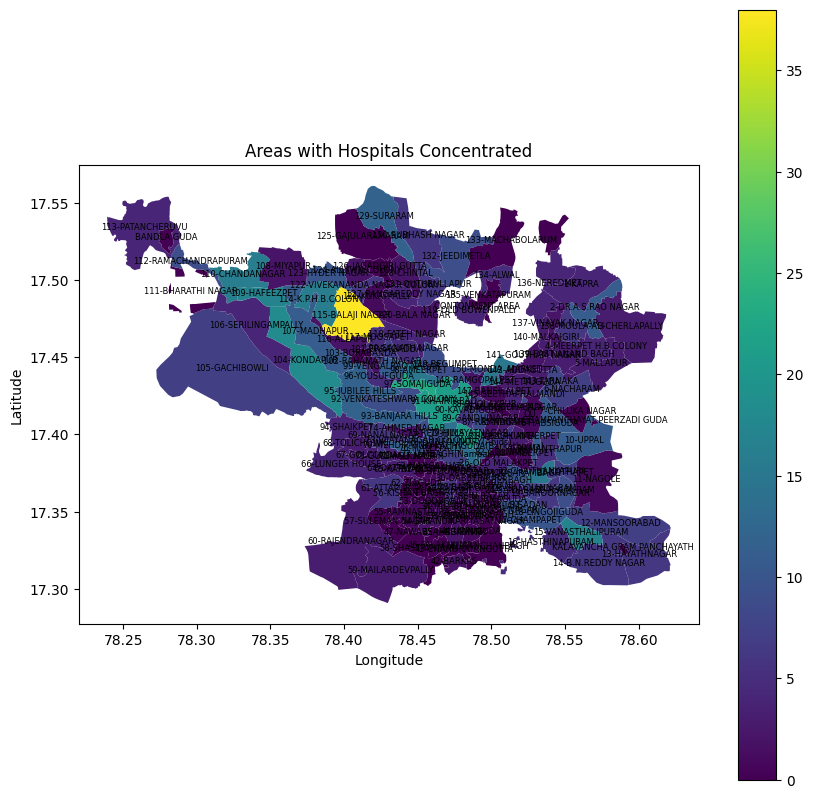

In [17]:
wards_4326 = wards.to_crs(epsg=4326)
import matplotlib.pyplot as plt

ax = wards_4326.plot(column="hospital_count", legend=True, figsize=(10, 10))

for idx, row in wards_4326.iterrows():
    plt.annotate(
        text=row["ward"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha="center",
        fontsize=6
    )
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Areas with Hospitals Concentrated")
plt.show()

#### Adding a Buffer Range of 2km to the Geometry

In [18]:
hospital_buffer2k = hospitals.copy()
hospital_buffer2k["geometry"] = hospital_buffer2k.geometry.buffer(2000)

#### Finding the Percentage of Area Covered Within 2km Radius of Hospitals in Each Ward

In [19]:
buffer_union = hospital_buffer2k.geometry.union_all()
wards["buffer_area"] = wards.geometry.intersection(buffer_union).area
wards["total_area"] = wards.geometry.area
wards["coverage%"] = wards["buffer_area"] / wards["total_area"]

#### Calculating Area-Weighted Population per Ward

In [ ]:
import pandas as pd
wards["AREA_IN_SQ"] = pd.to_numeric(wards["AREA_IN_SQ"], errors="coerce")

print(wards["AREA_IN_SQ"].isnull().sum())
total_area = wards["AREA_IN_SQ"].sum()
wards["population"] = (wards["AREA_IN_SQ"] / total_area) * 11608000



0


#### The Wards with Less Than 70% of Area Having Hospitals Within 2km Range are Assumed as Underserved Wards

In [28]:
wards["underserved"] = wards["coverage%"] < 0.7

#### There are Only 4 Underserved Wards

In [29]:
underserved_wards = wards[wards["underserved"] == True]
print(underserved_wards[["ward", "coverage%"]])

                  ward  coverage%
21   125-GAJULARAMARAM   0.487259
27      105-GACHIBOWLI   0.621034
65    133-MACHABOLARUM   0.478387
143      3-CHERLAPALLY   0.334628


#### As per the Estimations of Population and Calculations, There are a Total of 11.5 lakh Underserved Citizens

In [30]:
wards["underserved_pop"] = wards["population"] * (1 - wards["coverage%"])
total_underserved_pop = wards["underserved_pop"].sum()
print(total_underserved_pop)

1147235.607341705


#### ~10% of the Total Hyderabad Population is Underserved

In [31]:
percent_underserved = (total_underserved_pop / 11608000) * 100
print(percent_underserved)

9.883146169380641


#### Plotted the Hospital Coverage Percentage per Ward (within 2km radius of hospitals)

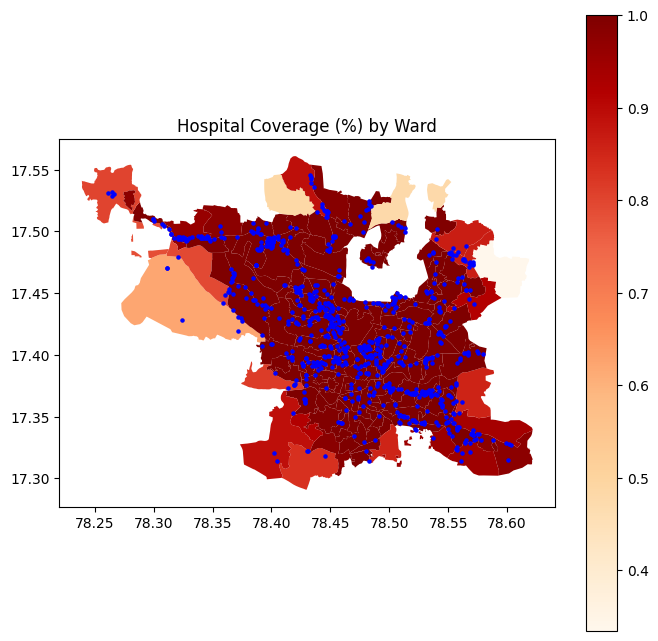

In [41]:
wards_4326 = wards.to_crs(epsg=4326)
hospitals_4326 = hospitals.to_crs(epsg=4326)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

wards_4326.plot(
    column="coverage%",
    cmap="OrRd",
    legend=True,
    ax=ax
)

hospitals_4326.plot(
    ax=ax,
    color="blue",
    markersize=5
)
plt.title("Hospital Coverage (%) by Ward")
plt.show()

#### Using K means clustering to cluster the data points on the map

In [33]:
import numpy as np

coords = np.array(list(zip(hospitals.geometry.x, hospitals.geometry.y)))

In [34]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(coords)

hospitals['cluster'] = labels

#### Verifying the Centers of the Clusters Formed

In [35]:
centers = kmeans.cluster_centers_
print(centers)

[[ 237875.18010835 1931273.43330981]
 [ 217175.10396855 1935086.68394398]
 [ 225829.21825866 1934766.60506326]
 [ 238153.4820713  1921155.22165626]
 [ 229768.58632774 1925889.29849247]]


#### Projecting to Degree Coordinate System to Plot the Clusters

In [36]:
wards = wards.to_crs(epsg=32644) 
hospitals = hospitals.to_crs(epsg=32644)

#### Converting the Coordinates to GeoData Frame

In [38]:
import geopandas as gpd
from shapely.geometry import Point

centroids_gdf = gpd.GeoDataFrame(
    geometry=[Point(xy) for xy in centers],
    crs="EPSG:32644"
)

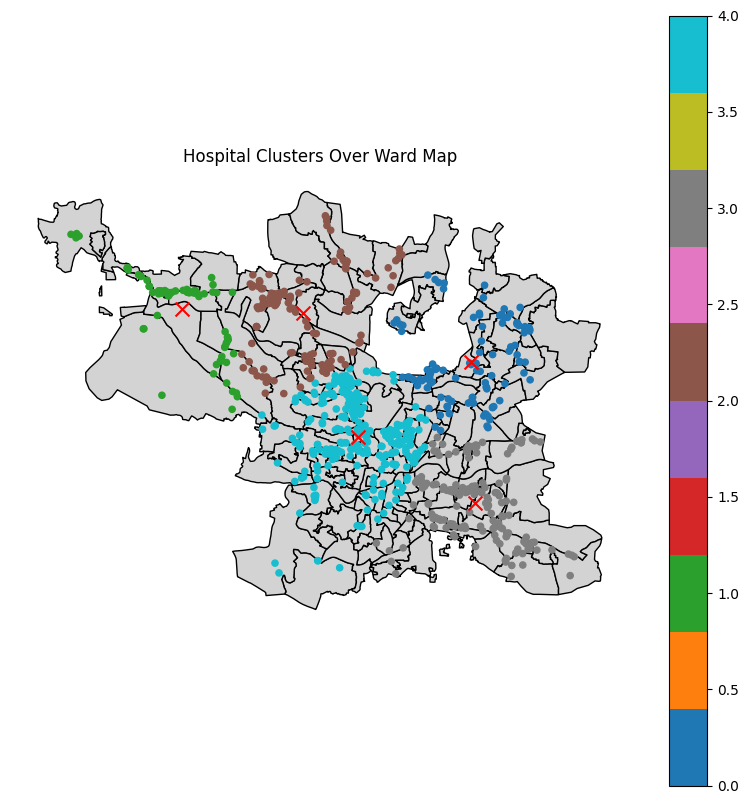

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

wards.plot(ax=ax, color='lightgrey', edgecolor='black')
hospitals.plot(ax=ax, column='cluster', cmap='tab10', markersize=20, legend=True)
centroids_gdf.plot(ax=ax, color='red', marker='x', markersize=100)

plt.title("Hospital Clusters Over Ward Map")
plt.axis('off')
plt.show()

#### Converting the Coordinate System Back to Degrees

In [40]:
hospitals = hospitals.to_crs(epsg=4326)
wards = wards.to_crs(epsg=4326)